### Great job! Now that you’ve seen the practical implementation of KNN Regression, it’s your turn to try it out. Using the Salary_dataset.csv file, predict people’s salaries based on their years of experience and implement KNN Regression on your own.

### **Import all the required libraries**

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###  **Load the dataset**

In [60]:
df = pd.read_csv('Salary_dataset.csv')
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


### **Let's perform some basic EDA like getting information about dataset, any null value present in column or not, top and last rows etc.**

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [62]:
df.isnull().sum()

,0
Unnamed: 0,0
YearsExperience,0
Salary,0


In [63]:
df = df.drop('Unnamed: 0',axis=1)

<Axes: xlabel='Salary', ylabel='Count'>

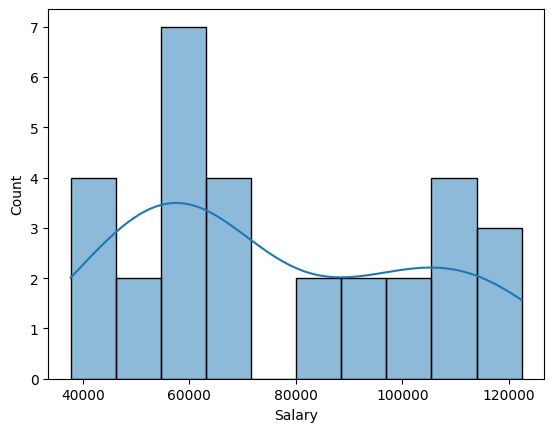

In [64]:
sns.histplot(df['Salary'],bins=10,kde=True)

<Axes: xlabel='YearsExperience', ylabel='Salary'>

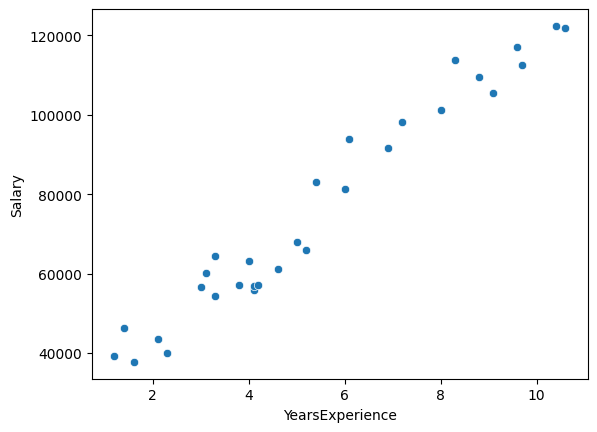

In [65]:
sns.scatterplot(x='YearsExperience',y='Salary',data=df)

### **Plot a scatter plot and view the realtion between Experience and  Salary**

### **Plot a trend line between Years of Experience and Salary**

<Axes: xlabel='YearsExperience', ylabel='Salary'>

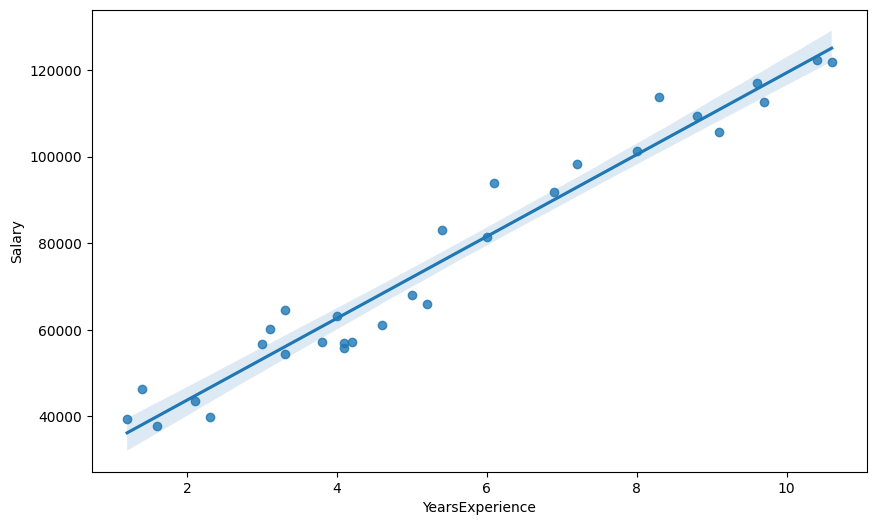

In [66]:
plt.figure(figsize=(10,6))
sns.regplot(x='YearsExperience',y='Salary',data=df)

### **Plots the distribution of salaries as a histogram with 10 bins and a smooth KDE curve, labeled with a title and x-axis name.**

Text(0.5, 0, 'Salary')

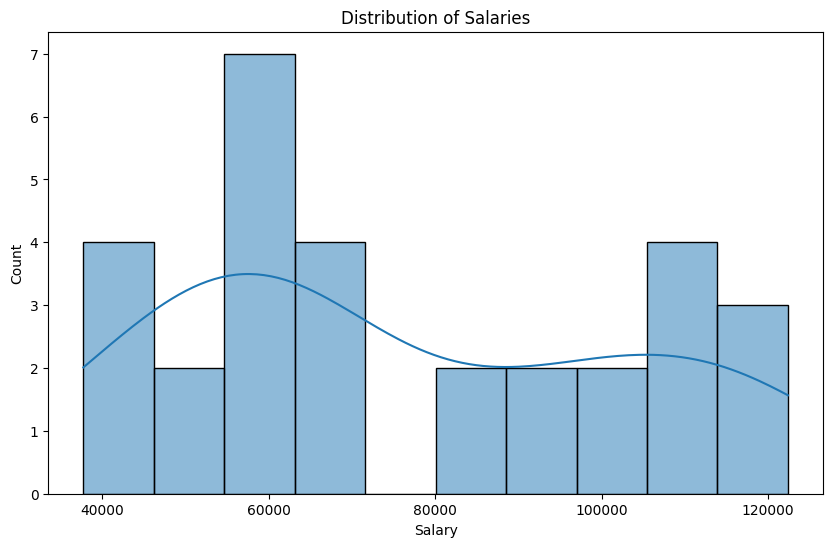

In [67]:
plt.figure(figsize=(10,6))
sns.histplot(df['Salary'],bins=10,kde=True)
plt.title('Distribution of Salaries')
plt.xlabel('Salary')

### **Compute the correlation matrix of the DataFrame and visualizes it as a color-coded heatmap with numeric annotations.**

<Axes: >

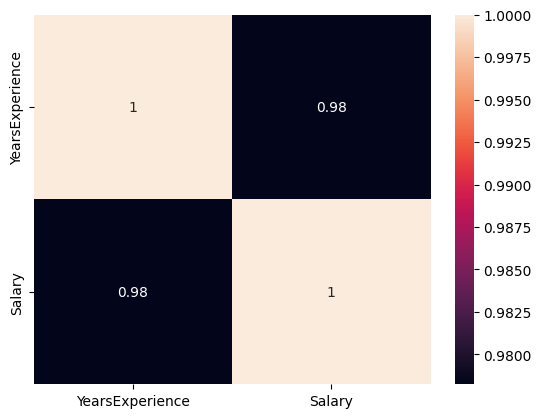

In [68]:
sns.heatmap(df.corr(),annot=True)

Now, let's split our dataset into features and target variable:

**X → independent variables (features)**

**y → dependent variable (target)**

This step is called selecting features and target for our model.

In [69]:
x = df.drop('Salary',axis=1)
y = df['Salary']

**After splitting the dataset into X (features) and y (target), the next step is to train our model on a portion of the data.**
Use train_test_split from skelearn.model_selection

In [70]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop('Salary',axis=1),df['Salary'],test_size=0.2,random_state=42)

**We know this no that `K-Nearest Neighbors (KNN)` is an algorithm that relies on distance between points. If the features are on different scales, the algorithm may give more importance to features with larger values, which can distort the results.**
we use StandardScaler to scale the features so that all of them contribute equally.

In [71]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


### Now, let's create a KNN regression model using sklearn.neighbors"

In [72]:
knn = KNeighborsRegressor(n_neighbors=3)

### Train X and y feature

In [73]:
knn.fit(x_train,y_train)

KNeighborsRegressor(n_neighbors=3)

### Make prediction on X_test

In [74]:
y_pred = knn.predict(x_test)

### Finally, we have created our KNN model, trained it on X_train and y_train, and made predictions. Now, let's evaluate how well the model is performing using the R² score.

In [75]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9407212188647607

### We vary n_neighbors from 1 to 15, train KNN each time, record the R² score, and pick the value that gives the best performance.

In [76]:
scores = []
for i in range(1,16):
    knn = KNeighborsRegressor(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    scores.append(r2_score(y_test,y_pred))

In [77]:
scores

[0.8021759743735162,
 0.9217065509837155,
 0.9407212188647607,
 0.9121083610592358,
 0.9014140752957686,
 0.8829697152225169,
 0.8795990047118195,
 0.8569250960063297,
 0.8501562896913797,
 0.8787729066478689,
 0.8097573846604605,
 0.7463611878468934,
 0.6655495569413946,
 0.6037594369599891,
 0.530005663284373]

### We plot n_neighbors (1–15) on the x-axis against their R² scores on the y-axis to visualize performance changes.

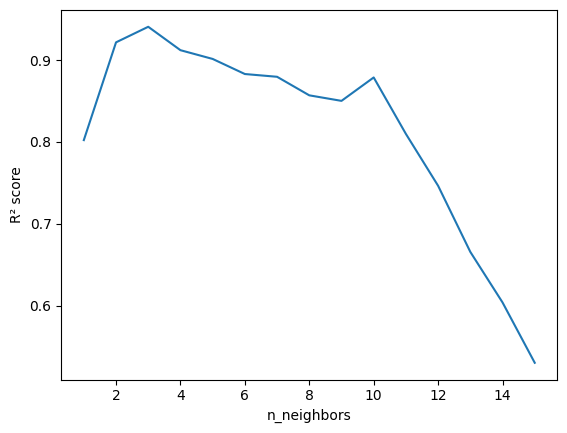

In [78]:
plt.plot(range(1,16),scores)
plt.xlabel('n_neighbors')
plt.ylabel('R² score')
plt.show()

In [79]:
import pickle

# Save the scaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print('Scaler saved to scaler.pkl')

Scaler saved to scaler.pkl


In [80]:
# Save the KNN model
with open('knn_model.pkl', 'wb') as file:
    pickle.dump(knn, file)

print('KNN model saved to knn_model.pkl')

KNN model saved to knn_model.pkl
